# Week 13

# Lecture 21: Data Visualization (MDS, Decision Trees, and t-SNE)

We will compare several views of class structure. PCA provides a linear projection, multidimensional scaling (MDS) preserves pairwise distances, and t-SNE emphasizes local neighborhoods. A decision tree provides a complementary, interpretable view of which measured variables predict the classes.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.manifold import MDS, TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree


## Breast Cancer: MDS and t-SNE class views

Both algorithms operate on standardized measurements. t-SNE coordinates and axis directions do not have direct feature meanings, so we will use supervised feature importance afterward to investigate likely drivers of the class split.


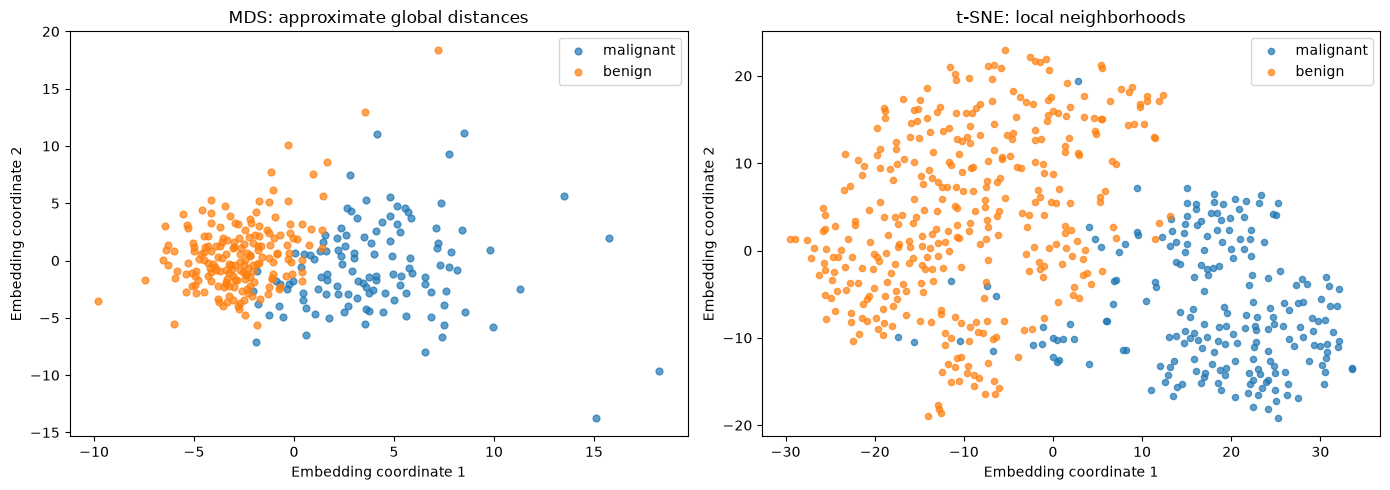

In [2]:
cancer = load_breast_cancer()
X = StandardScaler().fit_transform(cancer.data)
y = cancer.target

# Use a fixed sample to keep MDS fast and reproducible.
rng = np.random.default_rng(7)
sample = rng.choice(len(X), size=300, replace=False)
X_sample, y_sample = X[sample], y[sample]

mds = MDS(n_components=2, metric='euclidean', init='classical_mds',
          random_state=7, n_init=1)
Z_mds = mds.fit_transform(X_sample)

tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=7)
Z_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for class_id, class_name in enumerate(cancer.target_names):
    axes[0].scatter(Z_mds[y_sample == class_id, 0], Z_mds[y_sample == class_id, 1],
                    s=24, alpha=0.7, label=class_name)
    axes[1].scatter(Z_tsne[y == class_id, 0], Z_tsne[y == class_id, 1],
                    s=20, alpha=0.7, label=class_name)
axes[0].set_title('MDS: approximate global distances')
axes[1].set_title('t-SNE: local neighborhoods')
for ax in axes:
    ax.set_xlabel('Embedding coordinate 1')
    ax.set_ylabel('Embedding coordinate 2')
    ax.legend()
fig.tight_layout()
plt.show()


## Variables that drive the class split

An embedding shows separation but does not by itself prove which variables cause it. A shallow decision tree gives readable decision rules. Permutation importance measures how much held-out accuracy decreases when a variable is shuffled.


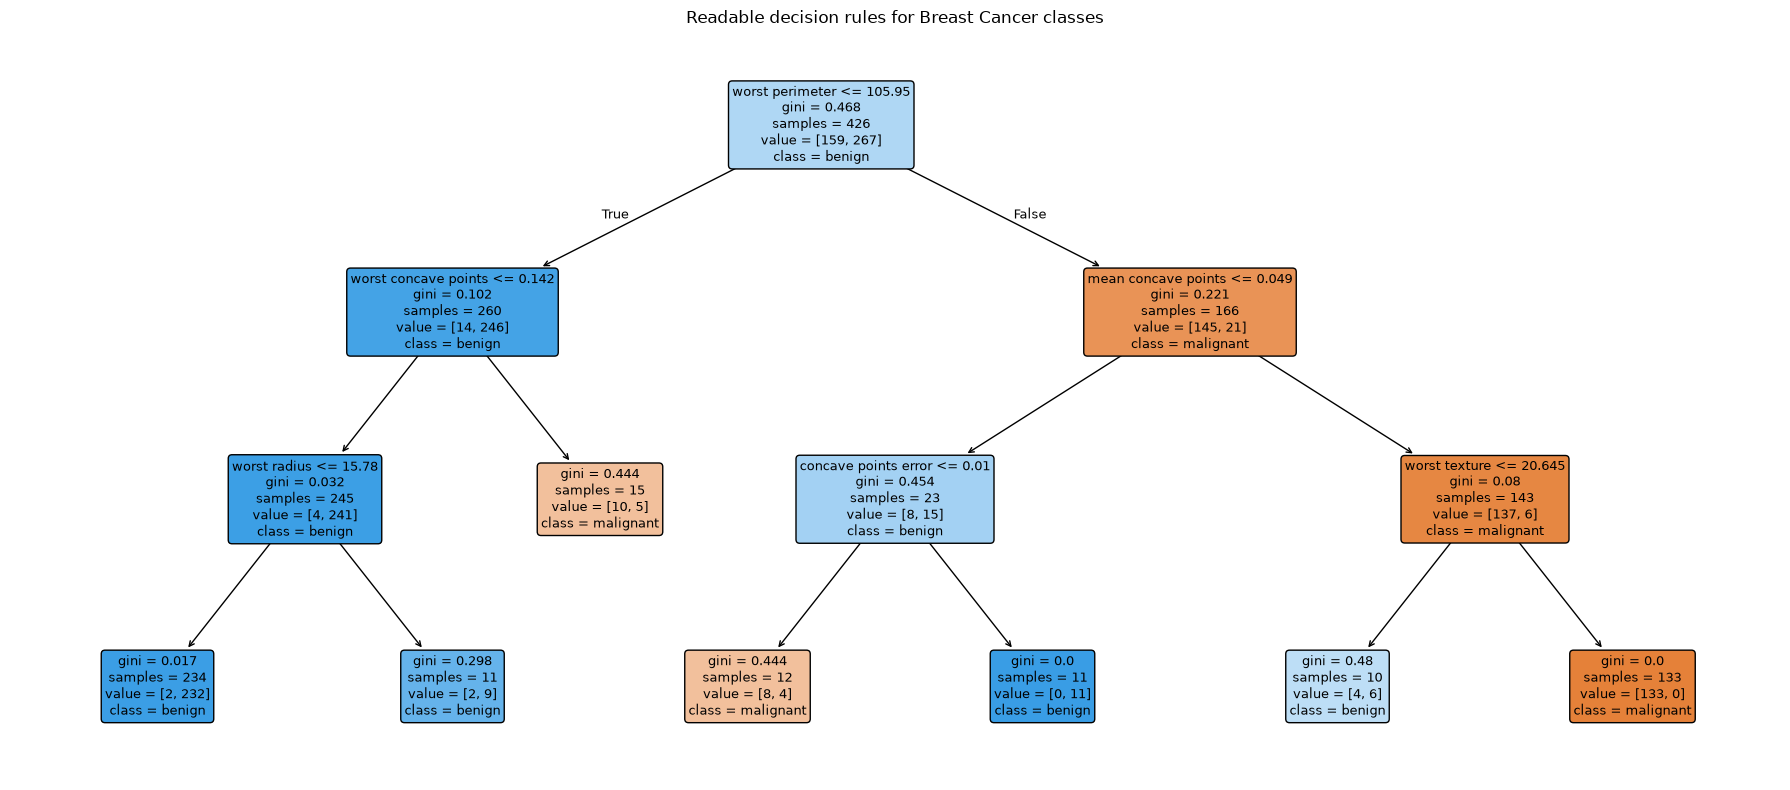

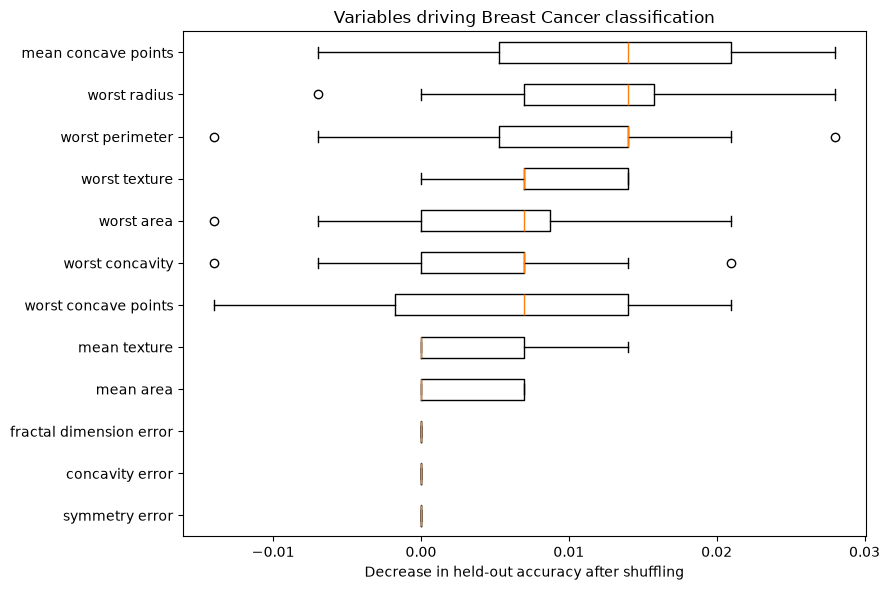

In [3]:
trainX, testX, trainY, testY = train_test_split(
    cancer.data, y, test_size=0.25, stratify=y, random_state=7
)

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=7)
tree.fit(trainX, trainY)

plt.figure(figsize=(18, 8))
plot_tree(tree, feature_names=cancer.feature_names, class_names=cancer.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title('Readable decision rules for Breast Cancer classes')
plt.tight_layout()
plt.show()

forest = RandomForestClassifier(n_estimators=400, min_samples_leaf=3, random_state=7, n_jobs=-1)
forest.fit(trainX, trainY)
importance = permutation_importance(forest, testX, testY, n_repeats=20, random_state=7, n_jobs=-1)
top = np.argsort(importance.importances_mean)[-12:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(importance.importances[top].T, orientation='horizontal',
           tick_labels=cancer.feature_names[top])
ax.set_xlabel('Decrease in held-out accuracy after shuffling')
ax.set_title('Variables driving Breast Cancer classification')
fig.tight_layout()
plt.show()


## Handwritten digits with t-SNE

This offline dataset is a small MNIST-style collection. t-SNE often produces visibly separated digit neighborhoods, although distances between far-apart clusters should not be over-interpreted.


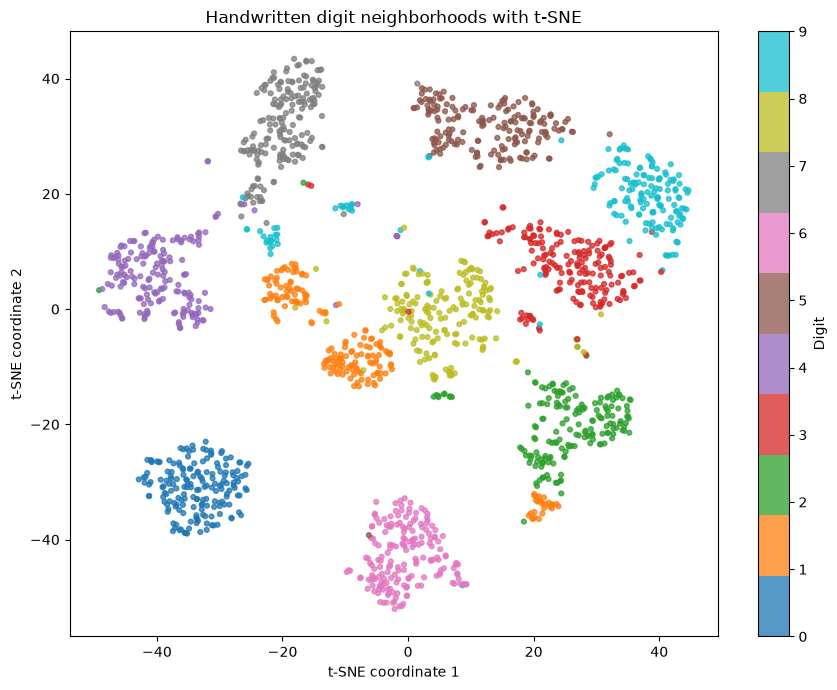

In [4]:
digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)
Z_digits = TSNE(perplexity=30, init='pca', learning_rate='auto', random_state=7).fit_transform(X_digits)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(Z_digits[:, 0], Z_digits[:, 1], c=digits.target,
                      cmap='tab10', s=12, alpha=0.75)
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.xlabel('t-SNE coordinate 1')
plt.ylabel('t-SNE coordinate 2')
plt.title('Handwritten digit neighborhoods with t-SNE')
plt.tight_layout()
plt.show()


# Lecture 22: Clustering and Expectation-Maximization

All clustering lectures use the Wine dataset. Its known cultivar labels are hidden during fitting and used only afterward to evaluate whether discovered clusters resemble the known classes.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = np.array(wine.feature_names)
X_scaled = StandardScaler().fit_transform(X_wine)

# Use the same two-dimensional PCA view in every clustering lecture.
pca = PCA(n_components=2)
X_view = pca.fit_transform(X_scaled)

def plot_clusters(labels, title, centers=None):
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        mask = labels == label
        name = 'Noise' if label == -1 else f'Cluster {label}'
        plt.scatter(X_view[mask, 0], X_view[mask, 1], s=35, alpha=0.75, label=name)
    if centers is not None:
        centers_view = pca.transform(centers)
        plt.scatter(centers_view[:, 0], centers_view[:, 1], marker='X', s=220,
                    c='black', edgecolor='white', label='Centers')
    plt.xlabel('Principal component 1')
    plt.ylabel('Principal component 2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def report_clustering(labels, name):
    clustered = labels != -1
    n_clusters = len(set(labels[clustered]))
    print(f'{name}: {n_clusters} clusters; {(~clustered).sum()} noise points')
    print('Adjusted Rand index:', round(adjusted_rand_score(y_wine, labels), 3))
    if n_clusters > 1 and clustered.sum() > n_clusters:
        print('Silhouette score:', round(silhouette_score(X_scaled[clustered], labels[clustered]), 3))


## K-means clustering

K-means alternates between assigning each observation to its nearest center and updating each center to the mean of its assigned observations.


K-means: 3 clusters; 0 noise points
Adjusted Rand index: 0.897
Silhouette score: 0.285


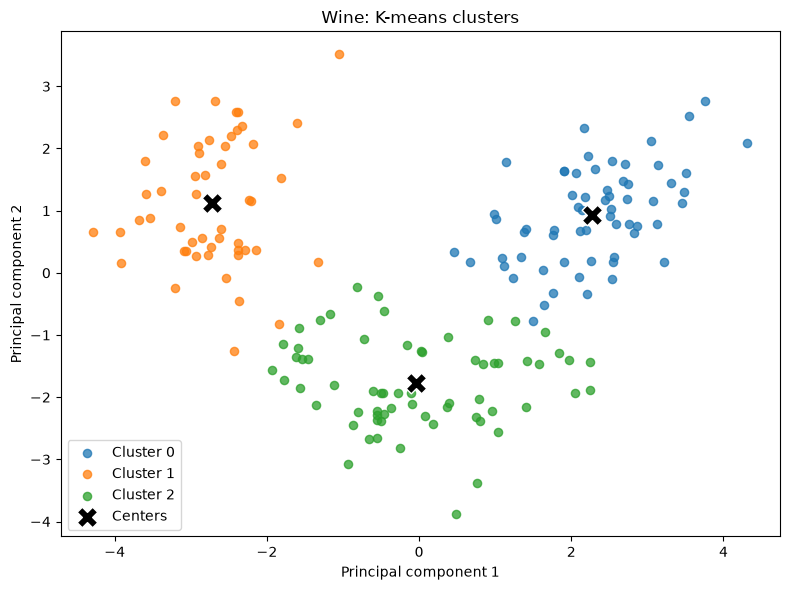

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=20, random_state=7)
kmeans_labels = kmeans.fit_predict(X_scaled)

report_clustering(kmeans_labels, 'K-means')
plot_clusters(kmeans_labels, 'Wine: K-means clusters', centers=kmeans.cluster_centers_)


## Expectation-Maximization from scratch

For a Gaussian mixture, the E-step computes soft membership probabilities (responsibilities). The M-step updates mixing weights, means, and covariance matrices using those responsibilities. We track log-likelihood to observe convergence.


EM Gaussian mixture: 3 clusters; 0 noise points
Adjusted Rand index: 0.946
Silhouette score: 0.278


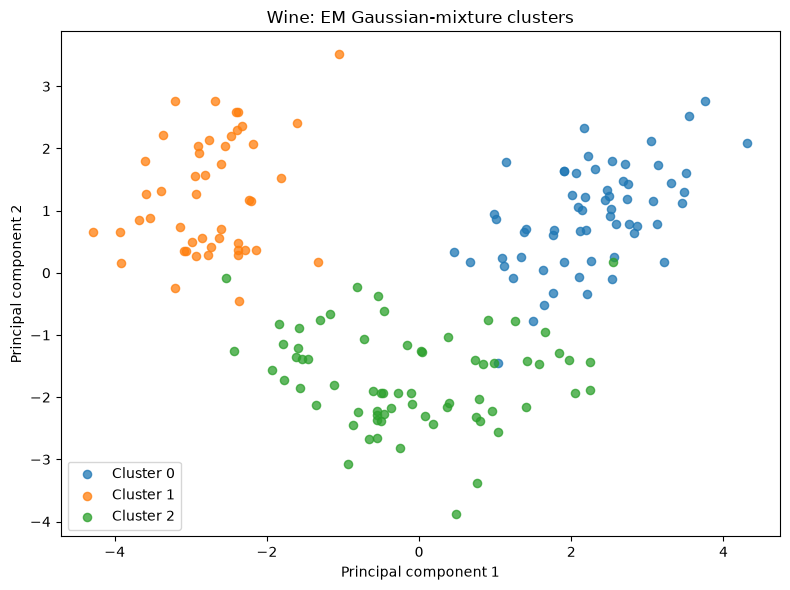

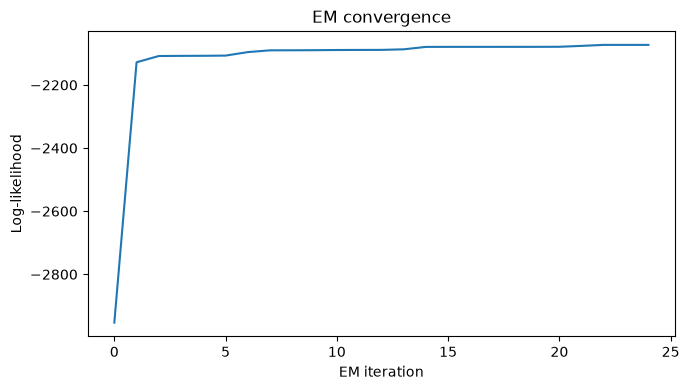

In [7]:
from scipy.special import logsumexp
from scipy.stats import multivariate_normal

def gaussian_mixture_em(X, n_components, max_iterations=200, tolerance=1e-5, random_state=7):
    n, d = X.shape
    # K-means++ provides a stable starting point; EM performs all later updates.
    means = KMeans(n_clusters=n_components, n_init=10,
                   random_state=random_state).fit(X).cluster_centers_
    covariances = np.array([np.eye(d) for _ in range(n_components)])
    weights = np.full(n_components, 1 / n_components)
    history = []

    for _ in range(max_iterations):
        # E-step: posterior cluster probabilities for every observation.
        log_joint = np.column_stack([
            np.log(weights[k]) + multivariate_normal.logpdf(
                X, mean=means[k], cov=covariances[k], allow_singular=True
            ) for k in range(n_components)
        ])
        log_normalizer = logsumexp(log_joint, axis=1, keepdims=True)
        responsibilities = np.exp(log_joint - log_normalizer)
        history.append(log_normalizer.sum())

        # M-step: weighted parameter estimates.
        effective_counts = responsibilities.sum(axis=0)
        weights = effective_counts / n
        means = (responsibilities.T @ X) / effective_counts[:, None]
        for k in range(n_components):
            centered = X - means[k]
            covariances[k] = (
                (responsibilities[:, k, None] * centered).T @ centered
                / effective_counts[k]
                + 1e-6 * np.eye(d)
            )

        if len(history) > 1 and abs(history[-1] - history[-2]) < tolerance:
            break

    return responsibilities.argmax(axis=1), responsibilities, np.array(history)

em_labels, responsibilities, log_likelihood = gaussian_mixture_em(X_scaled, 3)
report_clustering(em_labels, 'EM Gaussian mixture')
plot_clusters(em_labels, 'Wine: EM Gaussian-mixture clusters')

plt.figure(figsize=(7, 4))
plt.plot(log_likelihood)
plt.xlabel('EM iteration')
plt.ylabel('Log-likelihood')
plt.title('EM convergence')
plt.tight_layout()
plt.show()
